## import libraries

In [1]:
import pandas as pd
import numpy as np
import statistics as stats
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,PowerTransformer
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler


## load dataset

In [2]:
df_loan=pd.read_csv('loan_prediction.csv')

In [3]:
df_loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df=df_loan.copy() ## shallow copy

# drop unwanted columns

In [5]:
df.drop('Loan_ID',axis=1,inplace=True)

In [6]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
df['Gender']=df['Gender'].replace('Male','M')

In [8]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,M,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,M,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,M,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,M,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,M,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,M,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,M,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,M,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [9]:
df.shape

(614, 12)

## missing value treatment

In [10]:
df.isnull().sum().sum() ##overal all missing value

np.int64(149)

In [11]:
df.isnull().sum() ##missing values columns wise

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
miss_value=df.isnull().sum().sort_values(ascending=False)

In [13]:
miss_value

Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Education             0
ApplicantIncome       0
CoapplicantIncome     0
Property_Area         0
Loan_Status           0
dtype: int64

## percentage missing value

In [14]:
per_missing_value=round(((miss_value)/len(df))*100)

In [15]:
per_missing_value

Credit_History       8.0
Self_Employed        5.0
LoanAmount           4.0
Dependents           2.0
Loan_Amount_Term     2.0
Gender               2.0
Married              0.0
Education            0.0
ApplicantIncome      0.0
CoapplicantIncome    0.0
Property_Area        0.0
Loan_Status          0.0
dtype: float64

In [16]:
pd.concat([miss_value,per_missing_value],axis=1,keys=['miss_value','per_missing_value'])

,miss_value,per_missing_value
Credit_History,50,8.0
Self_Employed,32,5.0
LoanAmount,22,4.0
Dependents,15,2.0
Loan_Amount_Term,14,2.0
Gender,13,2.0
Married,3,0.0
Education,0,0.0
ApplicantIncome,0,0.0
CoapplicantIncome,0,0.0


<Axes: >

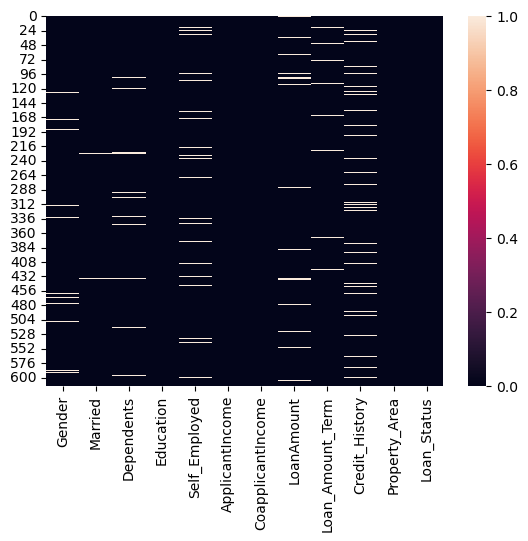

In [17]:
sns.heatmap(df.isnull())

In [18]:
df['Credit_History'].value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

In [19]:
#who ever has more than 6 is given as 1.

In [20]:
print(df['Credit_History'].mode())


0    1.0
Name: Credit_History, dtype: float64


In [21]:
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [22]:
print(df['Credit_History'].isnull().sum())

0


In [23]:
df['Credit_History'].value_counts()

Credit_History
1.0    525
0.0     89
Name: count, dtype: int64

In [24]:
df['Credit_History']=df['Credit_History'].astype(int)

In [25]:
df['Credit_History'].unique()

array([1, 0])

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     614 non-null    int64  
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 57.7+ KB


In [27]:
category_null=[i for i in df.columns if df[i].dtype==object and df[i].isnull().sum()>0] #list comprehensive

In [28]:
category_null

['Gender', 'Married', 'Dependents', 'Self_Employed']

In [29]:
for i in category_null:
    df[i]=df[i].fillna(df[i].mode()[0])

In [30]:
df.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [31]:
category_null

['Gender', 'Married', 'Dependents', 'Self_Employed']

<Axes: ylabel='LoanAmount'>

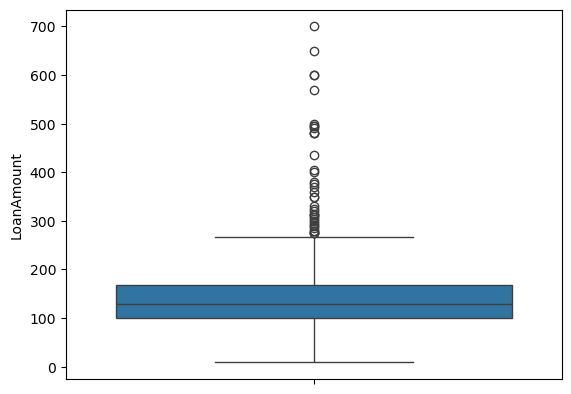

In [32]:
sns.boxplot(df['LoanAmount'])

In [33]:
df['LoanAmount'].value_counts()

LoanAmount
120.0    20
110.0    17
100.0    15
160.0    12
187.0    12
         ..
240.0     1
214.0     1
59.0      1
166.0     1
253.0     1
Name: count, Length: 203, dtype: int64

In [34]:
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].median())

In [35]:
df['LoanAmount']

0      128.0
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: LoanAmount, Length: 614, dtype: float64

In [36]:
print(df['LoanAmount'].isnull().sum())

0


In [37]:
df["Loan_Amount_Term"].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [38]:
df["Loan_Amount_Term"]=df["Loan_Amount_Term"]/12

In [39]:
df["Loan_Amount_Term"].value_counts()

Loan_Amount_Term
30.0    512
15.0     44
40.0     15
25.0     13
20.0      4
7.0       4
10.0      3
5.0       2
3.0       2
1.0       1
Name: count, dtype: int64

In [40]:
print(df["Loan_Amount_Term"].mean())

28.5


In [41]:
print(df["Loan_Amount_Term"].mode())

0    30.0
Name: Loan_Amount_Term, dtype: float64


In [42]:
print(df["Loan_Amount_Term"].median())

30.0


In [43]:
df["Loan_Amount_Term"]=df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])

In [44]:
df["Loan_Amount_Term"]=df["Loan_Amount_Term"].astype(int)

In [45]:
df["Loan_Amount_Term"].value_counts()

Loan_Amount_Term
30    526
15     44
40     15
25     13
20      4
7       4
10      3
5       2
3       2
1       1
Name: count, dtype: int64

In [46]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## for pratical purpose

In [47]:
#Variance is a statistical measure of the dispersion or spread of data points around their average value (mean)

In [48]:
# standard deviation is a statistical measure of the amount of variation or dispersion in a set of data values. 
#A low standard deviation indicates data points are close to the mean, while a high standard deviation indicates they are spread out.
#It is calculated as the square root of variance, ensuring it has the same units as the data. 


In [49]:
df['Dependents'].value_counts()

Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

In [50]:
df['Dependents']=df['Dependents'].replace("3+",3)

In [51]:
df['Dependents'].value_counts()

Dependents
0    360
1    102
2    101
3     51
Name: count, dtype: int64

In [52]:
df['Dependents'].dtype

dtype('O')

In [53]:
df['Dependents']=df['Dependents'].astype(int)

In [54]:
## dupliccate rows

df.duplicated().sum()

np.int64(0)

In [55]:
## df.drop_duplicates()

In [56]:
## unwanted value

df.isin(["?"," ","-","*"]).sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Outlier Treatment

In [57]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,M,No,0,Graduate,No,5849,0.0,128.0,30,1,Urban,Y
1,M,Yes,1,Graduate,No,4583,1508.0,128.0,30,1,Rural,N
2,M,Yes,0,Graduate,Yes,3000,0.0,66.0,30,1,Urban,Y
3,M,Yes,0,Not Graduate,No,2583,2358.0,120.0,30,1,Urban,Y
4,M,No,0,Graduate,No,6000,0.0,141.0,30,1,Urban,Y


In [58]:
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.744300,5403.459283,1621.245798,145.752443,28.534202,0.855049
std,1.009623,6109.041673,2926.248369,84.107233,5.369052,0.352339
min,0.000000,150.000000,0.000000,9.000000,1.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.250000,30.000000,1.000000
50%,0.000000,3812.500000,1188.500000,128.000000,30.000000,1.000000
75%,1.000000,5795.000000,2297.250000,164.750000,30.000000,1.000000
max,3.000000,81000.000000,41667.000000,700.000000,40.000000,1.000000


<Axes: ylabel='ApplicantIncome'>

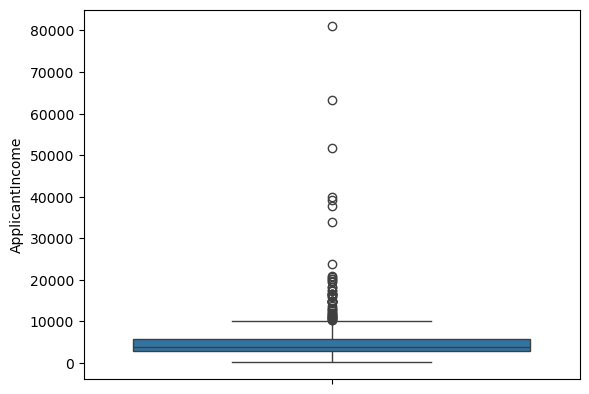

In [59]:
sns.boxplot(df["ApplicantIncome"])

<Axes: ylabel='CoapplicantIncome'>

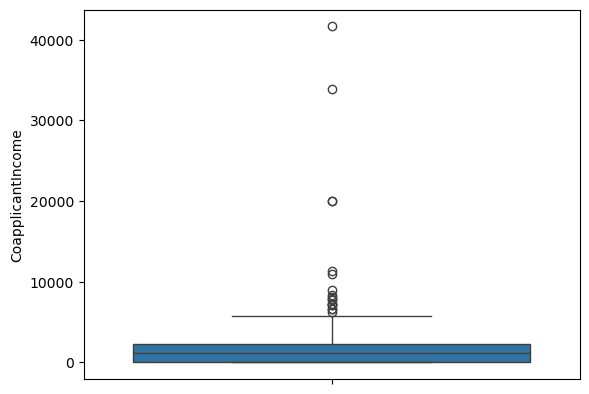

In [60]:
sns.boxplot(df["CoapplicantIncome"])

<Axes: ylabel='LoanAmount'>

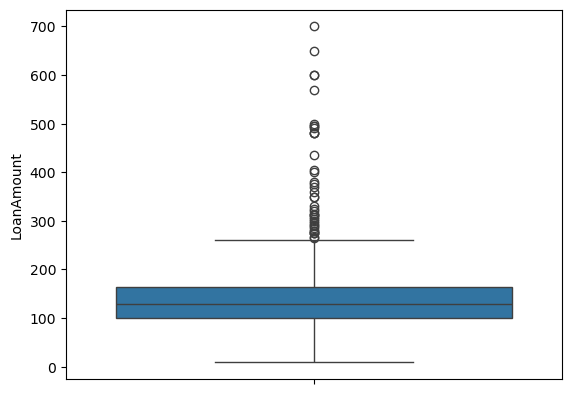

In [61]:
sns.boxplot(df["LoanAmount"])

In [62]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [63]:
outlier=df[['ApplicantIncome','CoapplicantIncome','LoanAmount']]

In [64]:
z=np.abs(zscore(outlier))

In [65]:
z

array([[0.07299082, 0.55448733, 0.21124125],
       [0.13441195, 0.03873155, 0.21124125],
       [0.39374734, 0.55448733, 0.94899647],
       ...,
       [0.43717437, 0.47240418, 1.27616847],
       [0.35706382, 0.55448733, 0.49081614],
       [0.13441195, 0.55448733, 0.15174486]], shape=(614, 3))

In [66]:
clean_data=df[(z<3).all(axis=1)]

In [67]:
outlier=df[(z>3).any(axis=1)]

In [68]:
df.shape

(614, 12)

In [69]:
clean_data.shape

(589, 12)

In [70]:
outlier.shape

(25, 12)

In [71]:
percentage_data_loss=(len(outlier)/len(df))*100

In [72]:
print(percentage_data_loss)

4.071661237785016


In [73]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 589 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             589 non-null    object 
 1   Married            589 non-null    object 
 2   Dependents         589 non-null    int64  
 3   Education          589 non-null    object 
 4   Self_Employed      589 non-null    object 
 5   ApplicantIncome    589 non-null    int64  
 6   CoapplicantIncome  589 non-null    float64
 7   LoanAmount         589 non-null    float64
 8   Loan_Amount_Term   589 non-null    int64  
 9   Credit_History     589 non-null    int64  
 10  Property_Area      589 non-null    object 
 11  Loan_Status        589 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 59.8+ KB


## Encoding

In [74]:
category=[i for i in clean_data.columns if clean_data[i].dtype==object]

In [75]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [76]:
for i in category:
    clean_data[i]=le.fit_transform(clean_data[i])

C:\Users\ACER\AppData\Local\Temp\ipykernel_31372\3311861074.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data[i]=le.fit_transform(clean_data[i])
C:\Users\ACER\AppData\Local\Temp\ipykernel_31372\3311861074.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data[i]=le.fit_transform(clean_data[i])
C:\Users\ACER\AppData\Local\Temp\ipykernel_31372\3311861074.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

In [77]:
clean_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,30,1,2,1
1,1,1,1,0,0,4583,1508.0,128.0,30,1,0,0
2,1,1,0,0,1,3000,0.0,66.0,30,1,2,1
3,1,1,0,1,0,2583,2358.0,120.0,30,1,2,1
4,1,0,0,0,0,6000,0.0,141.0,30,1,2,1


## Skewness

In [78]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,M,No,0,Graduate,No,5849,0.0,128.0,30,1,Urban,Y
1,M,Yes,1,Graduate,No,4583,1508.0,128.0,30,1,Rural,N
2,M,Yes,0,Graduate,Yes,3000,0.0,66.0,30,1,Urban,Y
3,M,Yes,0,Not Graduate,No,2583,2358.0,120.0,30,1,Urban,Y
4,M,No,0,Graduate,No,6000,0.0,141.0,30,1,Urban,Y


In [79]:
print(clean_data['ApplicantIncome'].skew())
print(clean_data['CoapplicantIncome'].skew())
print(clean_data['LoanAmount'].skew())

2.16476207904196
1.3531905540940208
1.114173164102511


In [80]:
clean_data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [81]:
skew=['ApplicantIncome','CoapplicantIncome','LoanAmount']

In [82]:
clean_data[skew].skew()

ApplicantIncome      2.164762
CoapplicantIncome    1.353191
LoanAmount           1.114173
dtype: float64

In [83]:
rm_skew=PowerTransformer()

In [84]:
clean_data[skew]=rm_skew.fit_transform(clean_data[skew])

C:\Users\ACER\AppData\Local\Temp\ipykernel_31372\2000158154.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data[skew]=rm_skew.fit_transform(clean_data[skew])


In [85]:
clean_data[skew].skew()

ApplicantIncome      0.028063
CoapplicantIncome   -0.186195
LoanAmount           0.061412
dtype: float64

C:\Users\ACER\AppData\Local\Temp\ipykernel_31372\732640404.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(clean_data['ApplicantIncome'])


<Axes: xlabel='ApplicantIncome', ylabel='Density'>

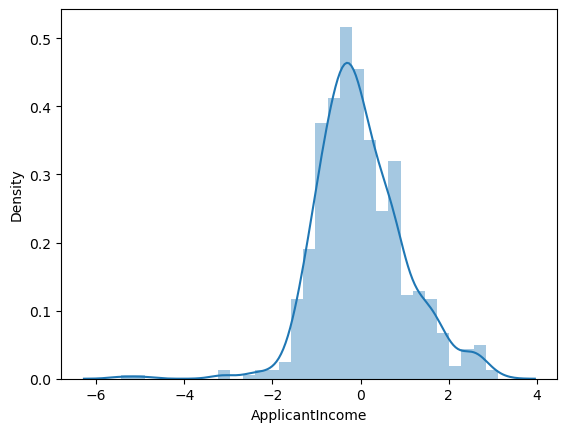

In [86]:
sns.distplot(clean_data['ApplicantIncome'])

In [87]:
clean_data['Loan_Status'].value_counts()

Loan_Status
1    407
0    182
Name: count, dtype: int64

In [88]:
## Splitting data in target and independent feature

x=clean_data.drop('Loan_Status',axis=1)
y=clean_data['Loan_Status']

### Oversampling using SMOTE

In [89]:
from imblearn.over_sampling import SMOTE

In [90]:
OS=SMOTE()

In [91]:
x,y=OS.fit_resample(x,y)

In [92]:
y.value_counts()

Loan_Status
1    407
0    407
Name: count, dtype: int64

## Scaling

In [93]:
from sklearn.preprocessing import StandardScaler

In [94]:
scaler=StandardScaler()
x_scale=scaler.fit_transform(x)

## Train_Test_Split

In [95]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x_scale,y,test_size=0.2,random_state=42)

In [96]:
print("Trainning feature matrix size",x_train.shape)
print("Test feature matrix size",x_test.shape)

Trainning feature matrix size (651, 11)
Test feature matrix size (163, 11)
